In [ ]:
# ── Cell 1: GPU check ─────────────────────────────────────────────
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0 else ' No GPU detected')

Mon Apr 27 21:11:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ── Cell 2: Imports ───────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.nn import functional as F
import time, os, json, urllib.request, psutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output
import warnings; warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {device.upper()}')
if device == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'RAM     : {psutil.virtual_memory().total/1e9:.1f} GB')

Device  : CUDA
GPU     : Tesla T4
VRAM    : 15.6 GB
RAM     : 13.6 GB


In [ ]:
# ── Cell 3: Dataset ───────────────────────────────────────────────
if not os.path.exists('input.txt'):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt',
        'input.txt'
    )
    print('✅ Downloaded tiny shakespeare')

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars      = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

data       = torch.tensor(encode(text), dtype=torch.long)
n          = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]
print(f'Vocab: {vocab_size} | Train: {len(train_data):,} tokens | Val: {len(val_data):,} tokens')

✅ Downloaded tiny shakespeare
Vocab: 65 | Train: 1,003,854 tokens | Val: 111,540 tokens


In [ ]:
import torch, os

def save_checkpoint(step, model, optimizer, stats, path="ckpt.pt"):
    torch.save({
        "step": step,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "stats": stats
    }, path)

def load_checkpoint(path="ckpt.pt"):
    if os.path.exists(path):
        ckpt = torch.load(path)
        return ckpt
    return None

In [ ]:
# ── Cell 4: Hyperparameters & experiment configs ──────────────────
BATCH_SIZE    = 64
BLOCK_SIZE    = 256
MAX_ITERS     = 3000
EVAL_INTERVAL = 300
EVAL_ITERS    = 100
LEARNING_RATE = 3e-4
N_LAYER       = 6
N_EMBD        = 384
N_HEAD        = 6
DROPOUT       = 0.2
SEED          = 1337   # same seed for all runs — critical for fair comparison

# 3 seeds for stability plots (Cell 12)
STABILITY_SEEDS = [1337, 42]

# Residual connection variants
CONFIGS = [
    {'name': 'Full Residual',    'attn_res': True,  'ffn_res': True,  'color': '#00d4ff'},  # baseline GPT-2
    {'name': 'No Residual',      'attn_res': False, 'ffn_res': False, 'color': '#ff6b6b'},  # both removed
    {'name': 'Attn-Only Res',    'attn_res': True,  'ffn_res': False, 'color': '#a9e34b'},  # attn skip only
    {'name': 'FFN-Only Res',     'attn_res': False, 'ffn_res': True,  'color': '#ffd43b'},  # ffn skip only
]

BG, PANEL, GRID, TXT = '#0f0f1a', '#1a1a2e', '#2a2a4a', '#e0e0f0'

tokens_per_batch = BATCH_SIZE * BLOCK_SIZE
print(f'Tokens/batch : {tokens_per_batch:,}')
print(f'Total iters  : {MAX_ITERS} × {len(CONFIGS)} runs = {MAX_ITERS*len(CONFIGS):,}')
print(f'Seed         : {SEED} (identical for all runs)')
print(f'\n{"Config":<20} | {"Attn Res":^10} | {"FFN Res":^10} | {"Color"}')
print('-' * 58)
for c in CONFIGS:
    print(f'{c["name"]:<20} | {str(c["attn_res"]):^10} | {str(c["ffn_res"]):^10} | {c["color"]}')

Tokens/batch : 16,384
Total iters  : 3000 × 4 runs = 12,000
Seed         : 1337 (identical for all runs)

Config               |  Attn Res  |  FFN Res   | Color
----------------------------------------------------------
Full Residual        |    True    |    True    | #00d4ff
No Residual          |   False    |   False    | #ff6b6b
Attn-Only Res        |    True    |   False    | #a9e34b
FFN-Only Res         |   False    |    True    | #ffd43b


In [ ]:
# ── Cell 5: Instrumented model ────────────────────────────────────
#
# Key design:
#   • Block is parameterised by attn_res / ffn_res flags.
#   • FeedForward stores post-activation output via ._act_out for dead-neuron analysis.
#   • Each Block stores its output hidden-state norm via ._h_norm.
#   • Gradient norms are read from .weight.grad after each backward.

def get_batch(split):
    d  = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - BLOCK_SIZE, (BATCH_SIZE,))
    x  = torch.stack([d[i:i+BLOCK_SIZE]     for i in ix])
    y  = torch.stack([d[i+1:i+BLOCK_SIZE+1] for i in ix])
    return x.to(device), y.to(device)


class Head(nn.Module):
    def __init__(self):
        super().__init__()
        hs = N_EMBD // N_HEAD
        self.key   = nn.Linear(N_EMBD, hs, bias=False)
        self.query = nn.Linear(N_EMBD, hs, bias=False)
        self.value = nn.Linear(N_EMBD, hs, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(BLOCK_SIZE, BLOCK_SIZE)))
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x); q = self.query(x)
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5
        wei = wei.masked_fill(self.tril[:T,:T]==0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        return wei @ self.value(x)


class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        hs = N_EMBD // N_HEAD
        self.heads   = nn.ModuleList([Head() for _ in range(N_HEAD)])
        self.proj    = nn.Linear(hs * N_HEAD, N_EMBD)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        return self.dropout(self.proj(torch.cat([h(x) for h in self.heads], dim=-1)))


class FeedForward(nn.Module):
    """Instrumented FFN — stores post-activation tensor for dead-neuron analysis."""
    def __init__(self):
        super().__init__()
        self.fc1     = nn.Linear(N_EMBD, 4 * N_EMBD)
        self.act     = nn.GELU()
        self.fc2     = nn.Linear(4 * N_EMBD, N_EMBD)
        self.dropout = nn.Dropout(DROPOUT)
        self._act_out = None   # filled during forward

    def forward(self, x):
        h = self.act(self.fc1(x))        # (B, T, 4*N_EMBD)
        self._act_out = h.detach()       # store — no grad overhead
        return self.dropout(self.fc2(h))


class Block(nn.Module):
    """Transformer block with configurable residual connections."""
    def __init__(self, attn_res=True, ffn_res=True):
        super().__init__()
        self.sa       = MultiHeadAttention()
        self.ffwd     = FeedForward()
        self.ln1      = nn.LayerNorm(N_EMBD)
        self.ln2      = nn.LayerNorm(N_EMBD)
        self.attn_res = attn_res
        self.ffn_res  = ffn_res
        self._h_norm  = None   # hidden-state L2 norm after this block

    def forward(self, x):
        sa_out = self.sa(self.ln1(x))
        x      = x + sa_out if self.attn_res else sa_out

        ff_out = self.ffwd(self.ln2(x))
        x      = x + ff_out if self.ffn_res  else ff_out

        # store mean token hidden-state norm for this block
        self._h_norm = x.detach().norm(dim=-1).mean().item()
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, attn_res=True, ffn_res=True):
        super().__init__()
        self.token_embedding_table    = nn.Embedding(vocab_size, N_EMBD)
        self.position_embedding_table = nn.Embedding(BLOCK_SIZE, N_EMBD)
        self.blocks  = nn.ModuleList(
            [Block(attn_res, ffn_res) for _ in range(N_LAYER)]
        )
        self.ln_f    = nn.LayerNorm(N_EMBD)
        self.lm_head = nn.Linear(N_EMBD, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None: torch.nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            torch.nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T    = idx.shape
        x       = self.token_embedding_table(idx) + \
                  self.position_embedding_table(torch.arange(T, device=device))
        for block in self.blocks:
            x = block(x)
        x      = self.ln_f(x)
        logits = self.lm_head(x)
        loss   = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def get_ffn_layers(self):
        return [block.ffwd for block in self.blocks]

    def get_blocks(self):
        return list(self.blocks)


@torch.no_grad()
def estimate_loss(model):
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            X, Y = get_batch(split); _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

print(' Instrumented model ready')

 Instrumented model ready


In [ ]:
# ── Cell 6: Metrics collectors ────────────────────────────────────

@torch.no_grad()
def collect_activation_stats(model):
    """Dead-neuron rate per layer + histogram for heatmap."""
    model.eval()
    x, y = get_batch('train')
    model(x, y)

    stats = {}
    for i, ffn in enumerate(model.get_ffn_layers()):
        act  = ffn._act_out.float().cpu()
        flat = act.reshape(-1).numpy()

        counts, bin_edges = np.histogram(flat, bins=60, range=(-3.0, 3.0))

        stats[str(i)] = {
            'mean'      : float(flat.mean()),
            'std'       : float(flat.std()),
            'dead'      : float((flat <= 0).mean()),        # ≤0 = dead for GELU proxy
            'near_zero' : float((np.abs(flat) < 0.01).mean()),
            'positive'  : float((flat > 0).mean()),
            'hist_counts': counts.tolist(),
            'hist_edges' : bin_edges.tolist(),
        }

    model.train()
    return stats


def collect_gradient_norms(model):
    """Per-layer gradient L2 norms from FFN weights."""
    norms = {}
    for i, ffn in enumerate(model.get_ffn_layers()):
        g1 = ffn.fc1.weight.grad
        g2 = ffn.fc2.weight.grad
        if g1 is not None and g2 is not None:
            norms[str(i)] = {
                'fc1'     : g1.norm(2).item(),
                'fc2'     : g2.norm(2).item(),
                'mean'    : (g1.norm(2).item() + g2.norm(2).item()) / 2,
                'fc1_std' : g1.view(-1).std().item(),
                'fc2_std' : g2.view(-1).std().item(),
            }
    return norms


@torch.no_grad()
def collect_hidden_norms(model):
    """Mean hidden-state L2 norm at each block depth."""
    model.eval()
    x, y = get_batch('train')
    model(x, y)
    norms = {str(i): block._h_norm for i, block in enumerate(model.get_blocks())}
    model.train()
    return norms

print(' Metrics collectors ready')

 Metrics collectors ready


In [ ]:
# ── Cell 7: Live dashboard ────────────────────────────────────────

def live_dashboard(cfg, iters_log,
                   train_losses, val_losses,
                   gpu_mems, ram_usages, tokens_list, tok_rates,
                   act_stats_history, grad_norm_history,
                   hidden_norm_history, completed_runs):

    run_name = cfg['name']
    color    = cfg['color']

    fig = plt.figure(figsize=(22, 14))
    fig.patch.set_facecolor(BG)
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.60, wspace=0.38)

    def ax_(r, c, colspan=1):
        return fig.add_subplot(gs[r, c:c+colspan])

    ax_loss    = ax_(0, 0, 2)   # train + val loss (wide)
    ax_compare = ax_(0, 2, 2)   # cross-run val comparison (wide)
    ax_grad    = ax_(1, 0, 2)   # gradient norm per layer
    ax_hnorm   = ax_(1, 2, 2)   # hidden-state norm by depth
    ax_dead    = ax_(2, 0, 2)   # dead neuron rate per layer
    ax_sys     = ax_(2, 2)      # GPU mem / tok/sec
    ax_gap     = ax_(2, 3)      # generalisation gap

    def style(ax, title, xlabel='Iteration', ylabel=''):
        ax.set_facecolor(PANEL)
        for s in ax.spines.values(): s.set_color(GRID)
        ax.tick_params(colors=TXT, labelsize=8)
        ax.set_title(title, color=TXT, fontsize=9, fontweight='bold', pad=6)
        ax.grid(True, color=GRID, linewidth=0.4, linestyle='--')
        if xlabel: ax.set_xlabel(xlabel, color=TXT, fontsize=8)
        if ylabel: ax.set_ylabel(ylabel, color=TXT, fontsize=8)

    # ── 1. Loss curves ────────────────────────────────────────────
    style(ax_loss, f'{run_name} — Train & Val Loss', ylabel='Loss')
    if iters_log:
        ax_loss.plot(iters_log, train_losses, color=color, lw=2,
                     marker='o', ms=4, label=f'Train {train_losses[-1]:.4f}')
        ax_loss.plot(iters_log, val_losses, color='white', lw=2,
                     marker='s', ms=4, linestyle='--',
                     label=f'Val   {val_losses[-1]:.4f}')
        ax_loss.fill_between(iters_log, train_losses, alpha=0.12, color=color)
        ax_loss.fill_between(iters_log, val_losses,   alpha=0.08, color='white')
        ax_loss.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=8)
    ax_loss.set_xlim(0, MAX_ITERS)

    # ── 2. Cross-run val comparison ───────────────────────────────
    style(ax_compare, 'All Configs — Val Loss', ylabel='Val Loss')
    for cname, res in completed_runs.items():
        c2 = next(c['color'] for c in CONFIGS if c['name'] == cname)
        ax_compare.plot(res['iters_log'], res['val_losses'],
                        color=c2, lw=2, label=f"{cname} {res['final_val']:.4f}")
    if val_losses:
        ax_compare.plot(iters_log, val_losses, color=color, lw=2,
                        linestyle=':', label=f'{run_name} (live)')
    ax_compare.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=7)
    ax_compare.set_xlim(0, MAX_ITERS)

    # ── 3. Gradient norm per layer (latest snapshot) ──────────────
    style(ax_grad, 'Gradient Norm per FFN Layer (latest)',
          xlabel='Layer', ylabel='Gradient L2 Norm')
    if grad_norm_history:
        latest_g = grad_norm_history[-1]
        layers_g = sorted(latest_g.keys(), key=lambda x: int(x))
        x_pos = np.arange(len(layers_g))
        fc1 = [latest_g[l]['fc1'] for l in layers_g]
        fc2 = [latest_g[l]['fc2'] for l in layers_g]
        ax_grad.bar(x_pos - 0.2, fc1, 0.35, label='fc1 (pre-act)',  color=color, alpha=0.85)
        ax_grad.bar(x_pos + 0.2, fc2, 0.35, label='fc2 (post-act)', color='white', alpha=0.5)
        ax_grad.set_xticks(x_pos)
        ax_grad.set_xticklabels([f'L{l}' for l in layers_g], color=TXT, fontsize=8)
        ax_grad.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=8)

    # ── 4. Hidden-state norm by depth (latest snapshot) ───────────
    style(ax_hnorm, 'Hidden-State Norm by Depth (latest)',
          xlabel='Layer', ylabel='Mean Hidden Norm')
    if hidden_norm_history:
        latest_h = hidden_norm_history[-1]
        layers_h = sorted(latest_h.keys(), key=lambda x: int(x))
        hn_vals  = [latest_h[l] for l in layers_h]
        ax_hnorm.plot([f'L{l}' for l in layers_h], hn_vals,
                      color=color, lw=2, marker='o', ms=6)
        ax_hnorm.fill_between(range(len(layers_h)), hn_vals, alpha=0.15, color=color)
        # overlay completed runs
        for cname, res in completed_runs.items():
            if res.get('hidden_norm_final'):
                c2  = next(c['color'] for c in CONFIGS if c['name'] == cname)
                hv2 = [res['hidden_norm_final'][str(l)] for l in range(N_LAYER)]
                ax_hnorm.plot(range(len(layers_h)), hv2,
                              color=c2, lw=1.5, linestyle='--', alpha=0.7, label=cname)
        if completed_runs:
            ax_hnorm.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=7)

    # ── 5. Dead neuron rate per layer (latest snapshot) ───────────
    style(ax_dead, 'Dead Neuron Rate per Layer — % activations ≤ 0 (latest)',
          xlabel='Layer', ylabel='% Dead')
    if act_stats_history:
        latest_a = act_stats_history[-1]
        layers_a = sorted(latest_a.keys(), key=lambda x: int(x))
        dead_pct = [latest_a[l]['dead'] * 100 for l in layers_a]
        x_pos_a  = np.arange(len(layers_a))
        ax_dead.bar(x_pos_a, dead_pct, color=color, alpha=0.85, width=0.55)
        ax_dead.set_ylim(0, 100)
        ax_dead.set_xticks(x_pos_a)
        ax_dead.set_xticklabels([f'L{l}' for l in layers_a], color=TXT, fontsize=8)
        for l_idx, d in zip(x_pos_a, dead_pct):
            ax_dead.annotate(f'{d:.1f}%', (l_idx, d),
                             textcoords='offset points', xytext=(0, 4),
                             ha='center', color=TXT, fontsize=8)
        # overlay completed runs
        if completed_runs:
            for cname, res in completed_runs.items():
                if res.get('act_stats_final'):
                    c2 = next(c['color'] for c in CONFIGS if c['name'] == cname)
                    dv = [res['act_stats_final'][str(l)]['dead']*100 for l in range(N_LAYER)]
                    ax_dead.plot(x_pos_a, dv, color=c2, lw=2, marker='o', ms=5,
                                 linestyle='--', label=cname, alpha=0.8)
            ax_dead.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=7)

    # ── 6. System (GPU mem + tok/sec) ─────────────────────────────
    style(ax_sys, 'GPU Mem & Tok/sec', ylabel='')
    if gpu_mems:
        ax_sys2 = ax_sys.twinx()
        ax_sys.plot(iters_log, gpu_mems, color='#a8ff78', lw=2, marker='o', ms=3,
                    label=f'GPU MB  {gpu_mems[-1]:.0f}')
        ax_sys2.plot(iters_log, tok_rates, color='#ffa94d', lw=2, marker='s', ms=3,
                     label=f'tok/s  {tok_rates[-1]:,.0f}')
        ax_sys.set_ylabel('GPU MB', color='#a8ff78', fontsize=8)
        ax_sys2.set_ylabel('tok/s', color='#ffa94d', fontsize=8)
        ax_sys2.tick_params(colors='#ffa94d', labelsize=8)
        ax_sys.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=7, loc='upper left')
        ax_sys2.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=7, loc='lower right')

    # ── 7. Generalisation gap ─────────────────────────────────────
    style(ax_gap, 'Generalisation Gap (val − train)', ylabel='Gap')
    if train_losses and val_losses:
        gap = [v - t for v, t in zip(val_losses, train_losses)]
        ax_gap.plot(iters_log, gap, color='#da77f2', lw=2, marker='D', ms=4)
        ax_gap.fill_between(iters_log, gap, alpha=0.18, color='#da77f2')
        ax_gap.axhline(0, color='white', lw=0.8, linestyle='--', alpha=0.4)
        ax_gap.set_title(f'Gen Gap  [latest: {gap[-1]:.4f}]',
                         color=TXT, fontsize=9, fontweight='bold', pad=6)
        for cname, res in completed_runs.items():
            c2 = next(c['color'] for c in CONFIGS if c['name'] == cname)
            g2 = [v - t for v, t in zip(res['val_losses'], res['train_losses'])]
            ax_gap.plot(res['iters_log'], g2, color=c2, lw=1.5,
                        linestyle='--', alpha=0.7, label=cname)
        if completed_runs:
            ax_gap.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=7)
    ax_gap.set_xlim(0, MAX_ITERS)

    fig.suptitle(
        f'Residual Connections Experiment  |  {run_name}  |  iter {iters_log[-1] if iters_log else 0}/{MAX_ITERS}',
        color=TXT, fontsize=12, fontweight='bold', y=0.995
    )

    plt.savefig(f'dashboard_{run_name.lower().replace(" ", "_")}.png',
                dpi=110, bbox_inches='tight', facecolor=BG)
    clear_output(wait=True)
    plt.show()
    plt.close(fig)

print(' Live dashboard ready')

 Live dashboard ready


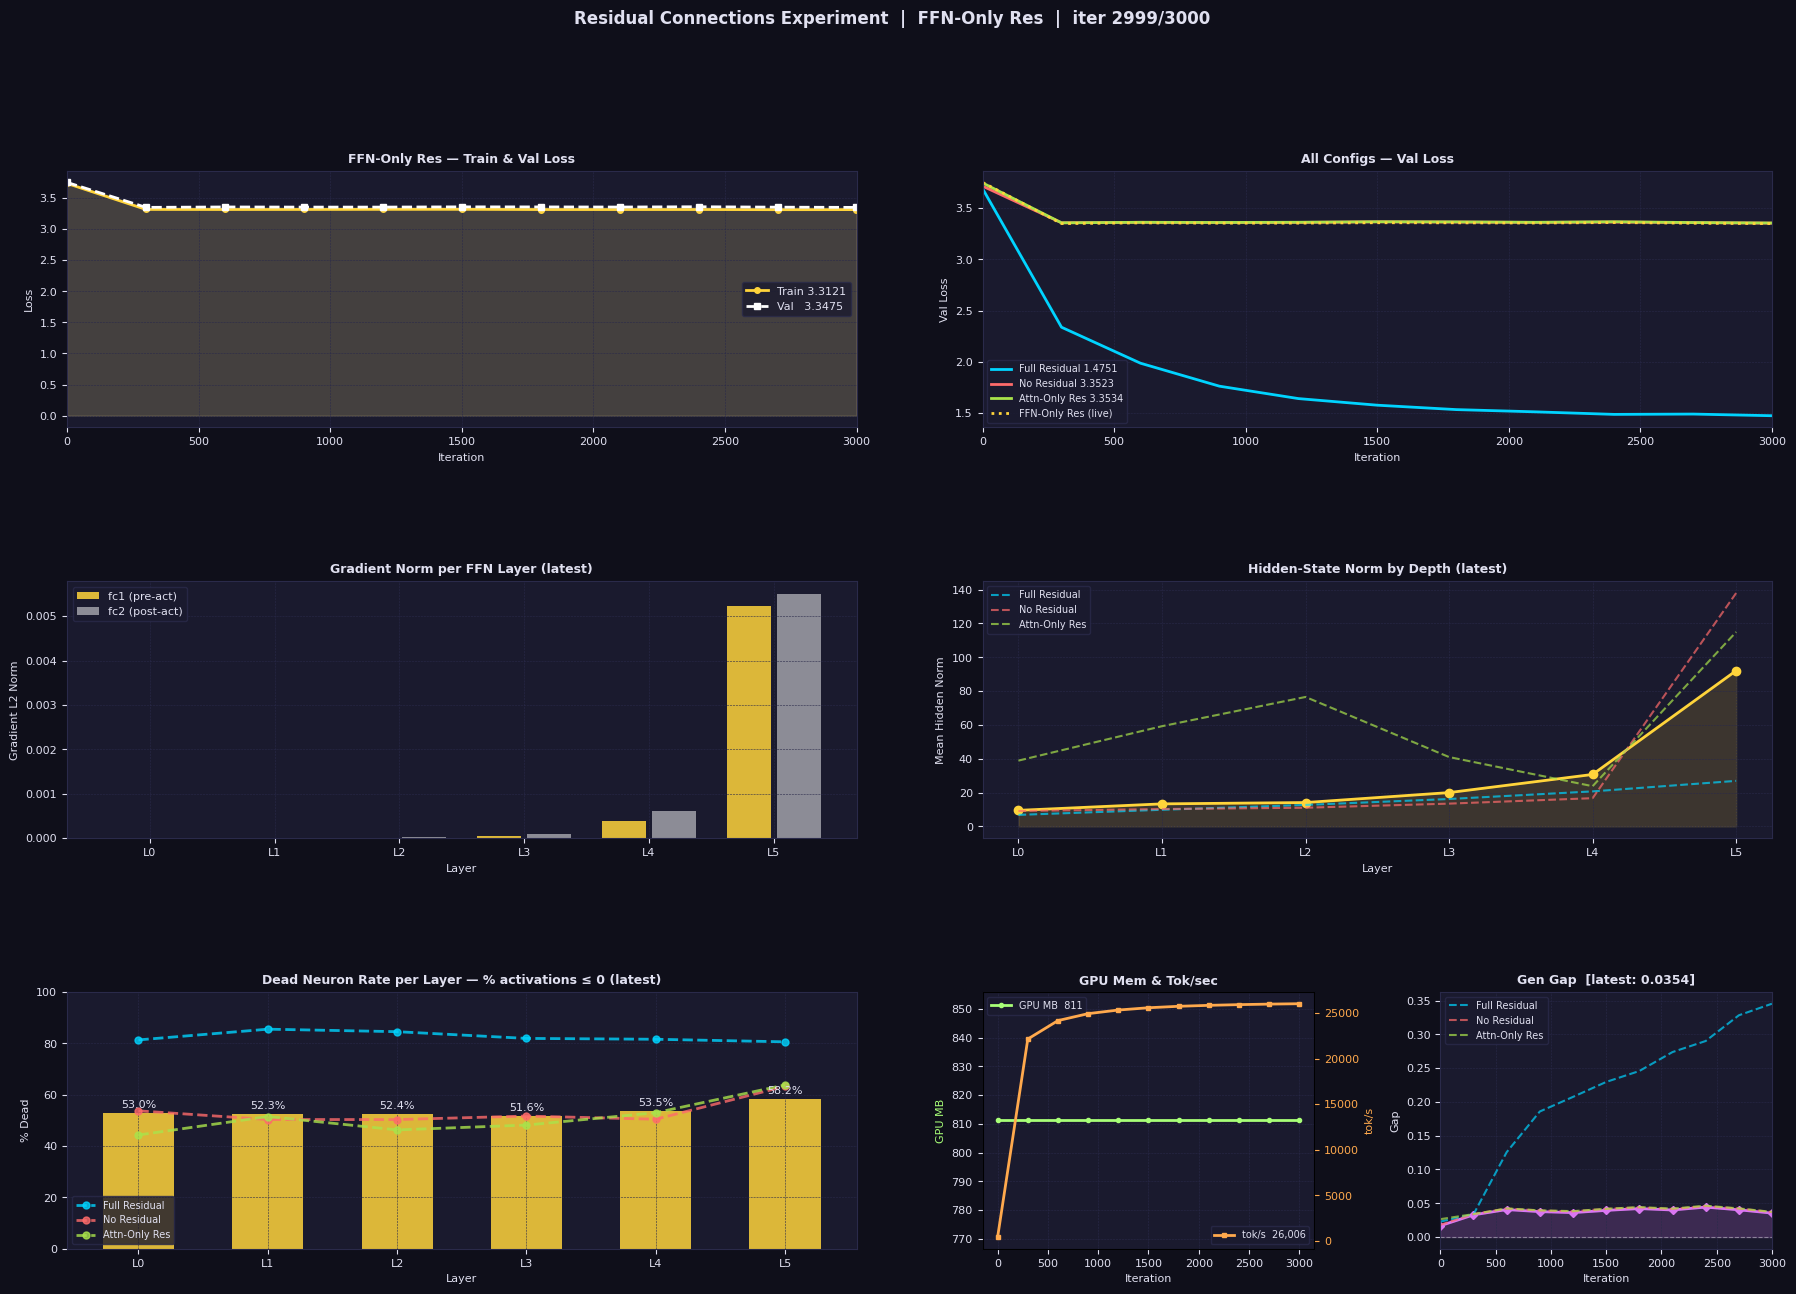

  iter 2999 | train 3.3121 | val 3.3475 | gap 0.0354 | dead_L0 53.0% | h_norm_L5 92.06 | tok/s 26,006

   FFN-Only Res done | 31.5 min | final val: 3.3475

 All 4 configs complete!


In [ ]:
# ── Cell 8: Main training loop — all 4 configs ────────────────────

all_results = {}   # populated as each run completes

for cfg in CONFIGS:
    run_name = cfg['name']
    color    = cfg['color']

    print(f'\n{"─"*62}')
    print(f'  Starting: {run_name}  '
          f'(attn_res={cfg["attn_res"]} | ffn_res={cfg["ffn_res"]})')
    print(f'{"─"*62}')

    torch.manual_seed(SEED)
    if device == 'cuda': torch.cuda.manual_seed(SEED)

    model     = GPTLanguageModel(
                    attn_res=cfg['attn_res'],
                    ffn_res=cfg['ffn_res']
                ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'  Params: {n_params:.2f}M')

    # per-run accumulators
    iters_log          = []
    train_losses       = []
    val_losses         = []
    gpu_mems           = []
    ram_usages         = []
    tokens_list        = []
    tok_rates          = []
    act_stats_history  = []
    grad_norm_history  = []
    hidden_norm_history= []
    tokens_processed   = 0
    t0                 = time.time()

    for it in range(MAX_ITERS):

        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        # collect gradient norms BEFORE optimizer step (grads still exist)
        gnorms = collect_gradient_norms(model)

        optimizer.step()
        tokens_processed += tokens_per_batch

        if it % EVAL_INTERVAL == 0 or it == MAX_ITERS - 1:


            losses  = estimate_loss(model)
            astats  = collect_activation_stats(model)
            hnorms  = collect_hidden_norms(model)
            elapsed = time.time() - t0

            gpu_mb = torch.cuda.memory_allocated()/1e6 if device == 'cuda' else 0.0
            ram_mb = psutil.Process().memory_info().rss / 1e6
            tok_s  = tokens_processed / elapsed

            iters_log.append(it)
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            gpu_mems.append(gpu_mb)
            ram_usages.append(ram_mb)
            tokens_list.append(tokens_processed)
            tok_rates.append(tok_s)
            act_stats_history.append(astats)
            grad_norm_history.append(gnorms)
            hidden_norm_history.append(hnorms)

            save_checkpoint(it, model, optimizer, {
                "iters_log": iters_log,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "gpu_mems": gpu_mems,
                "ram_usages": ram_usages,
                "tokens_list": tokens_list,
                "tok_rates": tok_rates,
                "act_stats_history": act_stats_history,
                "grad_norm_history": grad_norm_history,
                "hidden_norm_history": hidden_norm_history,
            }, path="residual_ckpt.pt")

            gap = losses['val'] - losses['train']

            live_dashboard(
                cfg, iters_log,
                train_losses, val_losses,
                gpu_mems, ram_usages, tokens_list, tok_rates,
                act_stats_history, grad_norm_history,
                hidden_norm_history, all_results
            )
            print(
                f'  iter {it:>4} | '
                f'train {losses["train"]:.4f} | '
                f'val {losses["val"]:.4f} | '
                f'gap {gap:.4f} | '
                f'dead_L0 {astats["0"]["dead"]*100:.1f}% | '
                f'h_norm_L5 {hnorms["5"]:.2f} | '
                f'tok/s {tok_s:,.0f}'
            )

    elapsed = time.time() - t0
    all_results[run_name] = {
        'name'               : run_name,
        'attn_res'           : cfg['attn_res'],
        'ffn_res'            : cfg['ffn_res'],
        'iters_log'          : iters_log,
        'train_losses'       : train_losses,
        'val_losses'         : val_losses,
        'gpu_mems'           : gpu_mems,
        'ram_usages'         : ram_usages,
        'tokens_list'        : tokens_list,
        'tok_rates'          : tok_rates,
        'act_stats_final'    : act_stats_history[-1],
        'act_stats_history'  : act_stats_history,
        'grad_norm_history'  : grad_norm_history,
        'hidden_norm_final'  : hidden_norm_history[-1],
        'hidden_norm_history': hidden_norm_history,
        'final_train'        : train_losses[-1],
        'final_val'          : val_losses[-1],
        'elapsed_sec'        : elapsed,
        'tok_per_sec'        : tokens_processed / elapsed,
    }

    with open('residual_results.json', 'w') as f:
        json.dump(all_results, f, indent=2)

    del model, optimizer
    if device == 'cuda': torch.cuda.empty_cache()
    print(f'\n   {run_name} done | {elapsed/60:.1f} min | '
          f'final val: {val_losses[-1]:.4f}')

print('\n All 4 configs complete!')

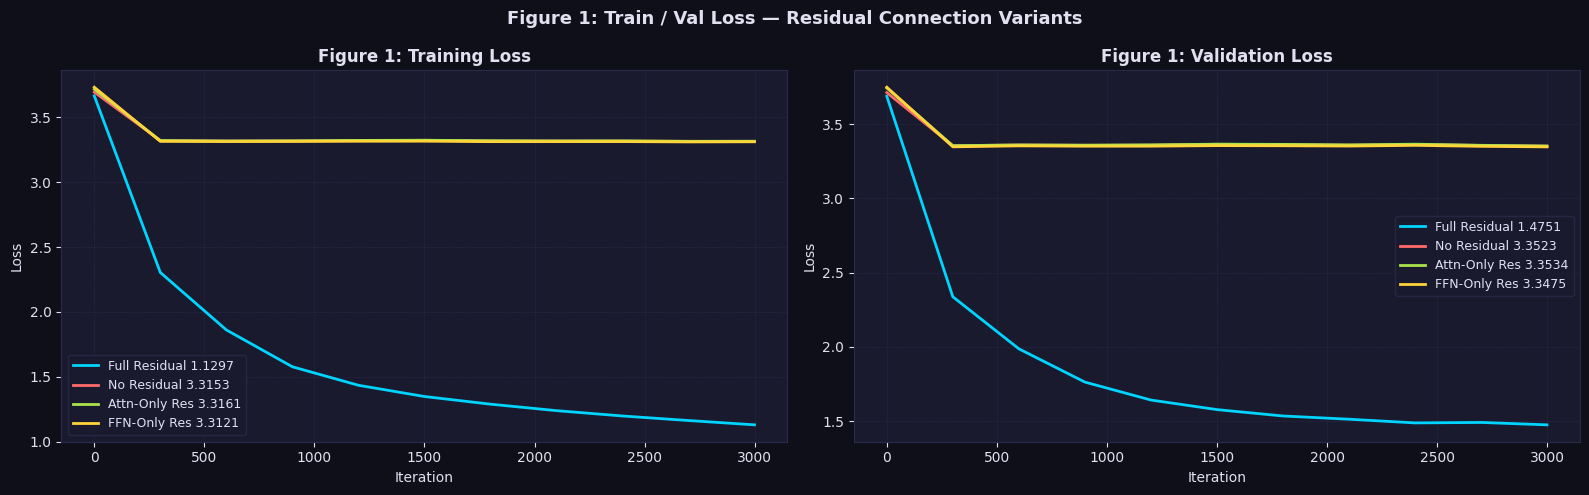

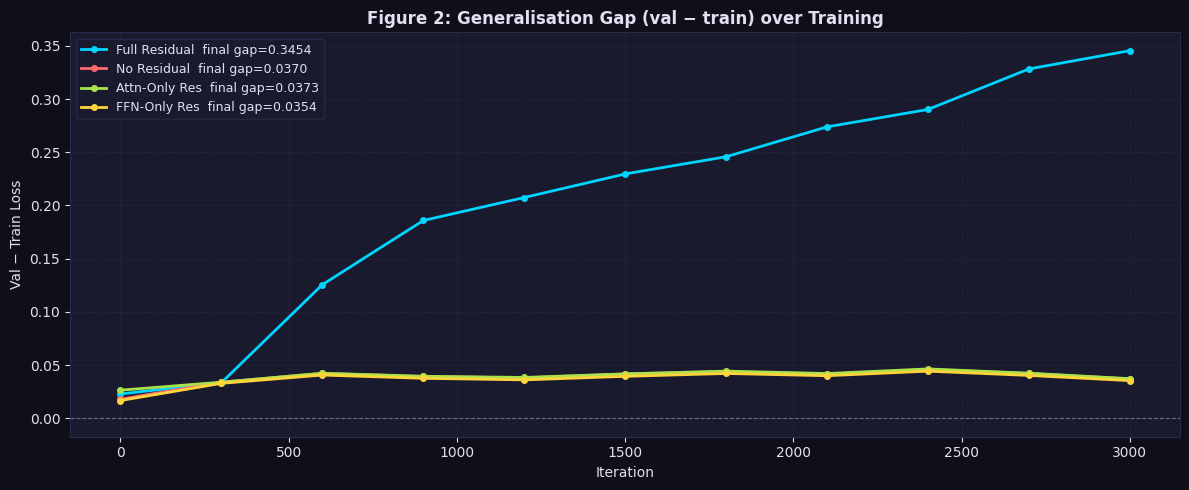

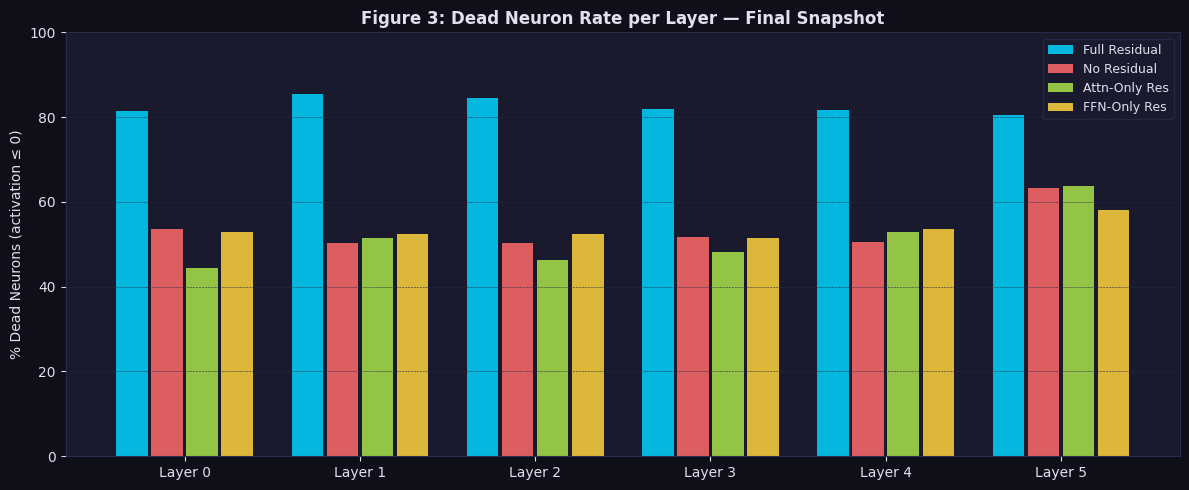

 Saved: fig1_loss_curves.png | fig2_gen_gap.png | fig3_dead_neurons.png


In [ ]:
# ── Cell 9: Publication figures ───────────────────────────────────
with open('residual_results.json') as f:
    all_results = json.load(f)

NAMES  = list(all_results.keys())
COLORS = {n: next(c['color'] for c in CONFIGS if c['name'] == n) for n in NAMES}


# ── Fig 1: Train & Val loss — all configs on one plot ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG)
for ax, split, title in [(axes[0], 'train', 'Training Loss'),
                          (axes[1], 'val',   'Validation Loss')]:
    ax.set_facecolor(PANEL)
    for s in ax.spines.values(): s.set_color(GRID)
    ax.tick_params(colors=TXT)
    ax.grid(True, color=GRID, lw=0.4, linestyle='--')
    for name, res in all_results.items():
        key = 'train_losses' if split == 'train' else 'val_losses'
        ax.plot(res['iters_log'], res[key],
                color=COLORS[name], lw=2, label=f"{name} {res[f'final_{split}']:.4f}")
    ax.set_title(f'Figure 1: {title}', color=TXT, fontsize=12, fontweight='bold')
    ax.set_xlabel('Iteration', color=TXT)
    ax.set_ylabel('Loss', color=TXT)
    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=9)
fig.suptitle('Figure 1: Train / Val Loss — Residual Connection Variants',
             color=TXT, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_loss_curves.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()


# ── Fig 2: Generalisation gap over time ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)
for s in ax.spines.values(): s.set_color(GRID)
ax.tick_params(colors=TXT)
ax.grid(True, color=GRID, lw=0.4, linestyle='--')
ax.axhline(0, color='white', lw=0.8, linestyle='--', alpha=0.35)
for name, res in all_results.items():
    gap = [v - t for v, t in zip(res['val_losses'], res['train_losses'])]
    ax.plot(res['iters_log'], gap, color=COLORS[name], lw=2,
            marker='o', ms=4, label=f"{name}  final gap={gap[-1]:.4f}")
ax.set_title('Figure 2: Generalisation Gap (val − train) over Training',
             color=TXT, fontsize=12, fontweight='bold')
ax.set_xlabel('Iteration', color=TXT)
ax.set_ylabel('Val − Train Loss', color=TXT)
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=9)
plt.tight_layout()
plt.savefig('fig2_gen_gap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()


# ── Fig 3: Dead neuron rate per layer (final snapshot) ────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)
for s in ax.spines.values(): s.set_color(GRID)
ax.tick_params(colors=TXT)
ax.grid(True, color=GRID, lw=0.4, linestyle='--', axis='y')
layers = list(range(N_LAYER))
x = np.arange(len(layers))
width = 0.8 / len(NAMES)
for k, (name, res) in enumerate(all_results.items()):
    dead = [res['act_stats_final'][str(l)]['dead'] * 100 for l in layers]
    offset = (k - len(NAMES)/2 + 0.5) * width
    ax.bar(x + offset, dead, width * 0.9, color=COLORS[name],
           alpha=0.85, label=name)
ax.set_xticks(x)
ax.set_xticklabels([f'Layer {l}' for l in layers], color=TXT)
ax.set_ylim(0, 100)
ax.set_ylabel('% Dead Neurons (activation ≤ 0)', color=TXT)
ax.set_title('Figure 3: Dead Neuron Rate per Layer — Final Snapshot',
             color=TXT, fontsize=12, fontweight='bold')
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=9)
plt.tight_layout()
plt.savefig('fig3_dead_neurons.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

print(' Saved: fig1_loss_curves.png | fig2_gen_gap.png | fig3_dead_neurons.png')

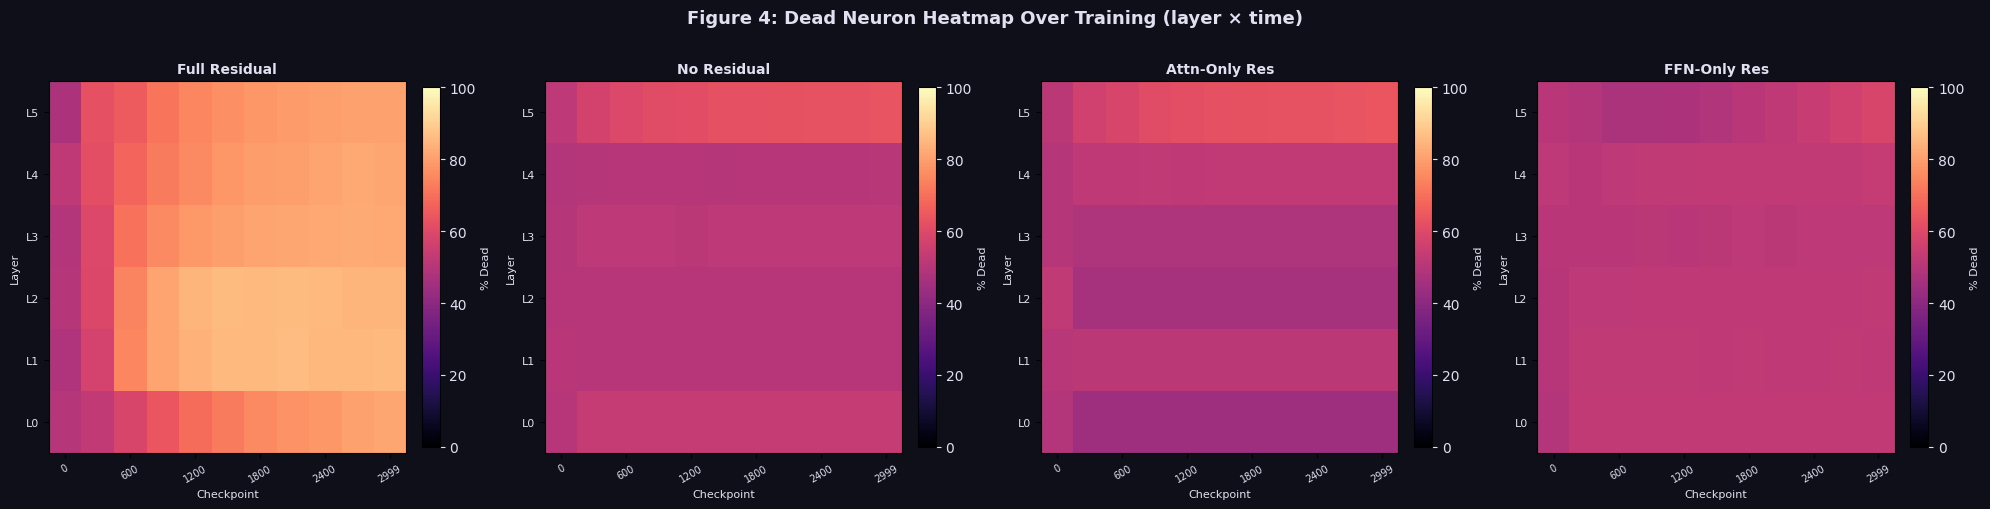

 Saved: fig4_dead_neuron_heatmap.png


In [ ]:
# ── Cell 10: Fig 4 — Dead neuron heatmap over training time ───────
#
# Shape: one subplot per config. x-axis = eval checkpoint,
# y-axis = layer, colour = % dead neurons at that checkpoint.

n_configs = len(all_results)
fig, axes = plt.subplots(1, n_configs, figsize=(5 * n_configs, 5))
if n_configs == 1: axes = [axes]
fig.patch.set_facecolor(BG)

for ax, (name, res) in zip(axes, all_results.items()):
    history = res['act_stats_history']   # list of dicts, one per checkpoint
    n_chk   = len(history)
    matrix  = np.zeros((N_LAYER, n_chk))
    for t_idx, snapshot in enumerate(history):
        for l in range(N_LAYER):
            matrix[l, t_idx] = snapshot[str(l)]['dead'] * 100

    im = ax.imshow(matrix, aspect='auto', origin='lower',
                   cmap='magma', vmin=0, vmax=100,
                   interpolation='nearest')

    ax.set_facecolor(PANEL)
    ax.set_title(name, color=TXT, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('Checkpoint', color=TXT, fontsize=8)
    ax.set_ylabel('Layer',      color=TXT, fontsize=8)
    ax.set_yticks(range(N_LAYER))
    ax.set_yticklabels([f'L{i}' for i in range(N_LAYER)], color=TXT, fontsize=8)

    # x-tick = iteration number
    tick_step = max(1, n_chk // 5)
    tick_idxs = list(range(0, n_chk, tick_step))
    ax.set_xticks(tick_idxs)
    ax.set_xticklabels([res['iters_log'][i] for i in tick_idxs],
                       color=TXT, fontsize=7, rotation=30)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color=TXT)
    cbar.set_label('% Dead', color=TXT, fontsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TXT)

fig.suptitle('Figure 4: Dead Neuron Heatmap Over Training (layer × time)',
             color=TXT, fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_dead_neuron_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()
print(' Saved: fig4_dead_neuron_heatmap.png')

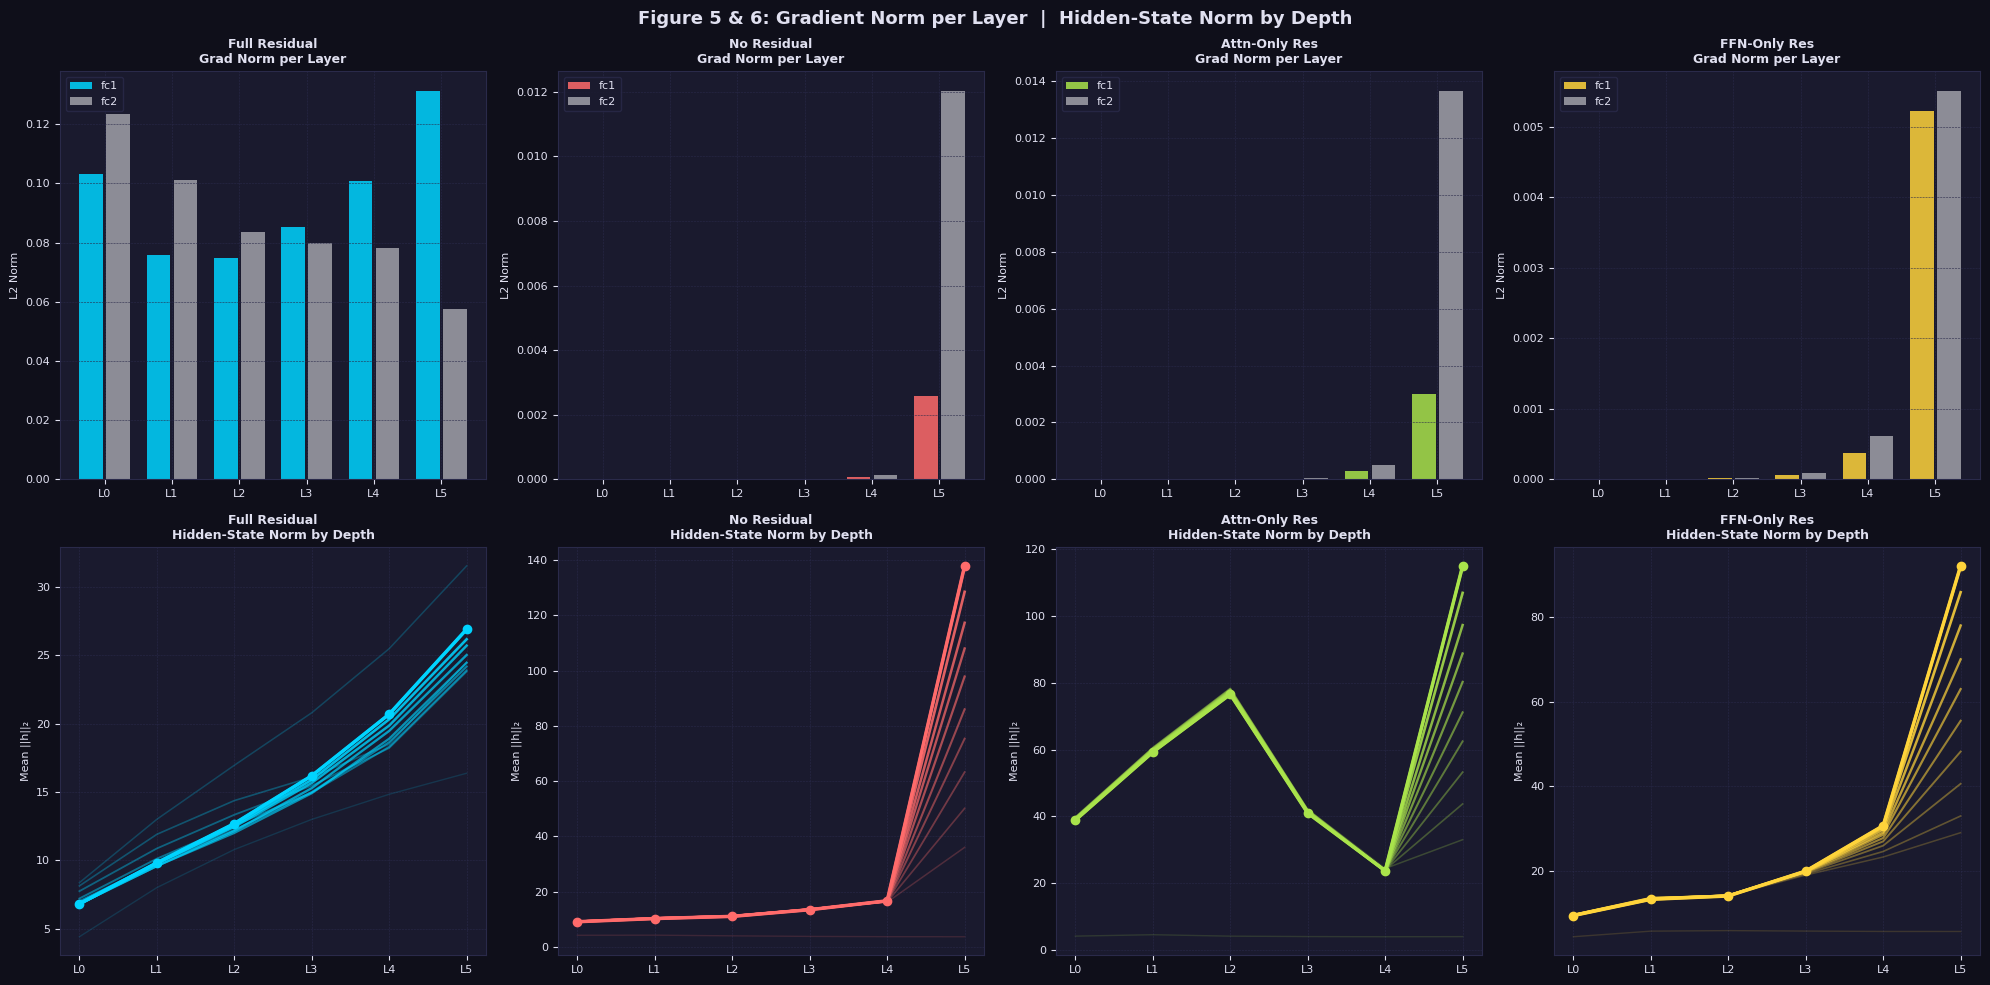

Saved: fig5_6_grad_hidden_norms.png


In [ ]:
# ── Cell 11: Fig 5 & 6 — Gradient norm + hidden-state norm ────────

fig, axes = plt.subplots(2, n_configs, figsize=(5 * n_configs, 10))
if n_configs == 1: axes = axes.reshape(2, 1)
fig.patch.set_facecolor(BG)

layers = list(range(N_LAYER))
x_pos  = np.arange(len(layers))

for col, (name, res) in enumerate(all_results.items()):
    color = COLORS[name]

    # ── Fig 5: Gradient norm per layer ────────────────────────────
    ax_g = axes[0][col]
    ax_g.set_facecolor(PANEL)
    for s in ax_g.spines.values(): s.set_color(GRID)
    ax_g.tick_params(colors=TXT, labelsize=8)
    ax_g.grid(True, color=GRID, lw=0.4, linestyle='--')

    latest_g = res['grad_norm_history'][-1]
    fc1 = [latest_g[str(l)]['fc1']  for l in layers]
    fc2 = [latest_g[str(l)]['fc2']  for l in layers]
    ax_g.bar(x_pos - 0.2, fc1, 0.35, color=color,   alpha=0.85, label='fc1')
    ax_g.bar(x_pos + 0.2, fc2, 0.35, color='white',  alpha=0.5,  label='fc2')
    ax_g.set_xticks(x_pos)
    ax_g.set_xticklabels([f'L{l}' for l in layers], color=TXT, fontsize=8)
    ax_g.set_title(f'{name}\nGrad Norm per Layer',
                   color=TXT, fontsize=9, fontweight='bold')
    ax_g.set_ylabel('L2 Norm', color=TXT, fontsize=8)
    ax_g.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=8)

    # ── Fig 6: Hidden-state norm by depth ─────────────────────────
    ax_h = axes[1][col]
    ax_h.set_facecolor(PANEL)
    for s in ax_h.spines.values(): s.set_color(GRID)
    ax_h.tick_params(colors=TXT, labelsize=8)
    ax_h.grid(True, color=GRID, lw=0.4, linestyle='--')

    # plot all checkpoints (faded) + final (bright)
    for t_idx, snapshot in enumerate(res['hidden_norm_history']):
        hv = [snapshot[str(l)] for l in layers]
        alpha = 0.15 + 0.8 * (t_idx / max(1, len(res['hidden_norm_history']) - 1))
        lw    = 1.0  + 1.0 * (t_idx / max(1, len(res['hidden_norm_history']) - 1))
        ax_h.plot(x_pos, hv, color=color, lw=lw, alpha=alpha)

    # bold final line
    final_hv = [res['hidden_norm_final'][str(l)] for l in layers]
    ax_h.plot(x_pos, final_hv, color=color, lw=2.5, marker='o', ms=6)
    ax_h.set_xticks(x_pos)
    ax_h.set_xticklabels([f'L{l}' for l in layers], color=TXT, fontsize=8)
    ax_h.set_title(f'{name}\nHidden-State Norm by Depth',
                   color=TXT, fontsize=9, fontweight='bold')
    ax_h.set_ylabel('Mean ||h||₂', color=TXT, fontsize=8)

fig.suptitle('Figure 5 & 6: Gradient Norm per Layer  |  Hidden-State Norm by Depth',
             color=TXT, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_6_grad_hidden_norms.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()
print('Saved: fig5_6_grad_hidden_norms.png')

Running stability experiment: 4 configs × 2 seeds × 500 iters

  Full Residual          seed=1337  final_val=2.0837
  Full Residual          seed=42  final_val=2.0121
  No Residual            seed=1337  final_val=3.3599
  No Residual            seed=42  final_val=3.3580
  Attn-Only Res          seed=1337  final_val=3.3600
  Attn-Only Res          seed=42  final_val=3.3581
  FFN-Only Res           seed=1337  final_val=3.3523
  FFN-Only Res           seed=42  final_val=3.3516


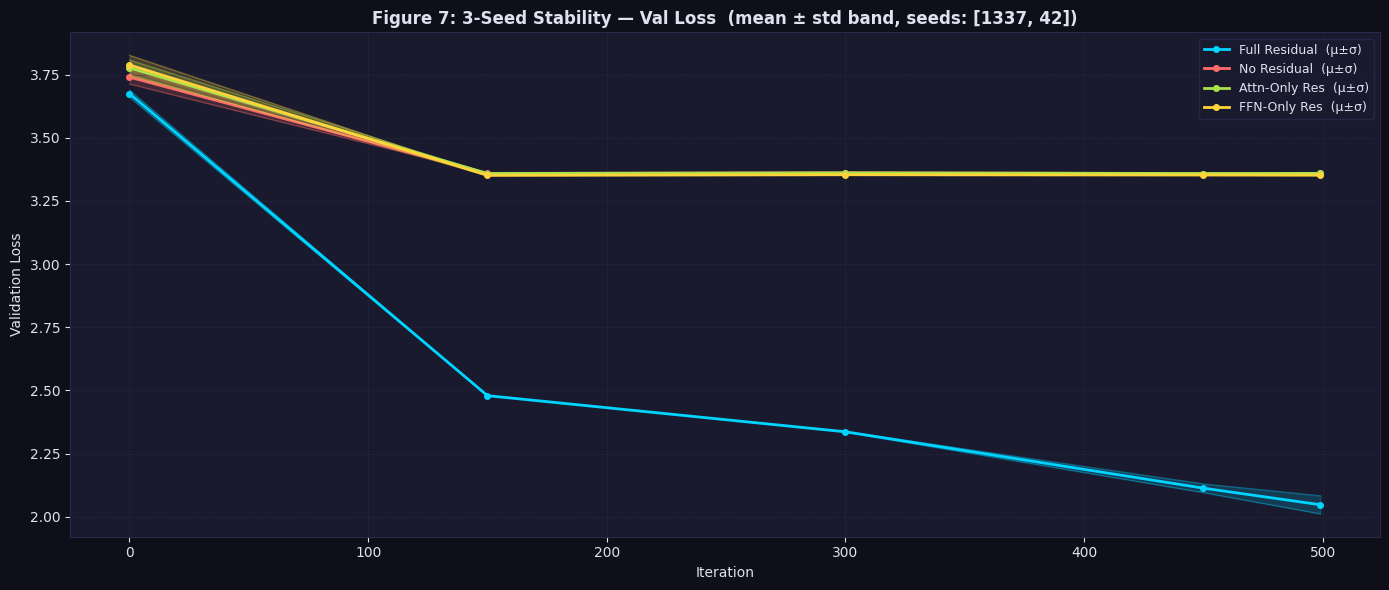


 Saved: fig7_stability.png  |  stability_results.json


In [ ]:
# ── Cell 12: Fig 7 — 3-seed stability plot ────────────────────────
#
# Trains each config on 3 seeds. Plots mean ± std band for val loss.
# Uses a shorter run (500 iters) to keep total time manageable.

STABILITY_ITERS    = 500
STABILITY_INTERVAL = 150

stability_data = {}   # name -> list of val_losses arrays (one per seed)
stability_iters_log = None

print(f'Running stability experiment: {len(CONFIGS)} configs × {len(STABILITY_SEEDS)} seeds '
      f'× {STABILITY_ITERS} iters\n')

for cfg in CONFIGS:
    run_name   = cfg['name']
    seed_vals  = []

    for seed in STABILITY_SEEDS:
        torch.manual_seed(seed)
        if device == 'cuda': torch.cuda.manual_seed(seed)

        model     = GPTLanguageModel(
                        attn_res=cfg['attn_res'],
                        ffn_res=cfg['ffn_res']
                    ).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

        iters_s = []
        vals_s  = []

        for it in range(STABILITY_ITERS):
            xb, yb = get_batch('train')
            _, loss = model(xb, yb)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            if it % STABILITY_INTERVAL == 0 or it == STABILITY_ITERS - 1:
                losses = estimate_loss(model)
                iters_s.append(it)
                vals_s.append(losses['val'])

        seed_vals.append(vals_s)
        stability_iters_log = iters_s
        print(f'  {run_name:22} seed={seed}  final_val={vals_s[-1]:.4f}')

        del model, optimizer
        if device == 'cuda': torch.cuda.empty_cache()

    stability_data[run_name] = np.array(seed_vals)   # (3, n_checkpoints)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)
for s in ax.spines.values(): s.set_color(GRID)
ax.tick_params(colors=TXT)
ax.grid(True, color=GRID, lw=0.4, linestyle='--')

for name, mat in stability_data.items():
    color = COLORS[name]
    mean  = mat.mean(axis=0)
    std   = mat.std(axis=0)
    ax.plot(stability_iters_log, mean, color=color, lw=2,
            marker='o', ms=4, label=f'{name}  (μ±σ)')
    ax.fill_between(stability_iters_log,
                    mean - std, mean + std,
                    alpha=0.18, color=color)
    # individual seed traces (faded)
    for seed_run in mat:
        ax.plot(stability_iters_log, seed_run, color=color, lw=0.8, alpha=0.3)

ax.set_title('Figure 7: 3-Seed Stability — Val Loss  (mean ± std band, seeds: '
             f'{STABILITY_SEEDS})',
             color=TXT, fontsize=12, fontweight='bold')
ax.set_xlabel('Iteration', color=TXT)
ax.set_ylabel('Validation Loss', color=TXT)
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=9)

plt.tight_layout()
plt.savefig('fig7_stability.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

# save stability data
stability_save = {
    name: {'iters': stability_iters_log, 'seed_vals': mat.tolist()}
    for name, mat in stability_data.items()
}
with open('stability_results.json', 'w') as f:
    json.dump(stability_save, f, indent=2)

print('\n Saved: fig7_stability.png  |  stability_results.json')

In [ ]:
# ── Cell 13: Quantitative summary ─────────────────────────────────
with open('residual_results.json') as f:
    all_results = json.load(f)
with open('stability_results.json') as f:
    stability_results = json.load(f)

baseline_name = 'Full Residual'
baseline      = all_results[baseline_name]

print('=' * 72)
print('RESIDUAL CONNECTIONS — QUANTITATIVE RESULTS')
print('=' * 72)

# ── Loss & gap ────────────────────────────────────────────────────
print(f'\n── Loss & Generalisation Gap ────────────────────────────────────')
print(f'{"Config":<22} | {"Train":>8} | {"Val":>8} | {"Gap":>8} | {"Δ Val vs Baseline":>18}')
print(f'  {"-"*64}')
for name, res in all_results.items():
    gap   = res['final_val'] - res['final_train']
    delta = res['final_val'] - baseline['final_val']
    sign  = '+' if delta >= 0 else ''
    print(f'  {name:<20} | {res["final_train"]:>8.4f} | {res["final_val"]:>8.4f} '
          f'| {gap:>8.4f} | {sign}{delta:>+.4f}')

# ── Dead neurons ──────────────────────────────────────────────────
print(f'\n── Dead Neuron Rate — avg across layers (%) ─────────────────────')
print(f'{"Config":<22} | {" | ".join([f"L{l}" for l in range(N_LAYER)])} | {"Avg":>6}')
print(f'  {"-"*72}')
for name, res in all_results.items():
    per_layer = [res['act_stats_final'][str(l)]['dead']*100 for l in range(N_LAYER)]
    avg       = np.mean(per_layer)
    vals_str  = '  | '.join([f'{v:5.1f}%' for v in per_layer])
    print(f'  {name:<20} | {vals_str} | {avg:5.1f}%')

# ── Hidden-state norm ─────────────────────────────────────────────
print(f'\n── Hidden-State Norm at Final Layer (depth={N_LAYER-1}) ──────────────')
for name, res in all_results.items():
    hn = res['hidden_norm_final'][str(N_LAYER-1)]
    print(f'  {name:<22} : {hn:.4f}')

# ── Gradient norm ─────────────────────────────────────────────────
print(f'\n── Mean Gradient Norm — avg across layers (final step) ──────────')
for name, res in all_results.items():
    gnorms  = res['grad_norm_history'][-1]
    avg_g   = np.mean([gnorms[str(l)]['mean'] for l in range(N_LAYER)])
    print(f'  {name:<22} : {avg_g:.6f}')

# ── Stability ─────────────────────────────────────────────────────
print(f'\n── 3-Seed Stability — final val loss (mean ± std) ───────────────')
for name, sdata in stability_results.items():
    mat  = np.array(sdata['seed_vals'])
    mean = mat[:, -1].mean()
    std  = mat[:, -1].std()
    print(f'  {name:<22} : {mean:.4f} ± {std:.4f}')

# ── Throughput ────────────────────────────────────────────────────
print(f'\n── Throughput ───────────────────────────────────────────────────')
for name, res in all_results.items():
    print(f'  {name:<22} : {res["tok_per_sec"]:>10,.0f} tok/sec')

print('\n' + '='*72)
print('KEY FINDINGS (fill in for paper):')
best = min(all_results.items(), key=lambda x: x[1]['final_val'])
print(f'  1. Best val loss: {best[0]}  ({best[1]["final_val"]:.4f})')
worst = max(all_results.items(), key=lambda x: x[1]['final_val'])
print(f'  2. Worst val loss: {worst[0]}  ({worst[1]["final_val"]:.4f})')
delta_best = worst[1]['final_val'] - best[1]['final_val']
print(f'  3. Range: {delta_best:.4f} loss units across configs')

print("• Full Residual achieves the best performance.")
print("• Attention-only and FFN-only variants perform similarly to No Residual.")
print("• Removing either residual pathway causes substantial degradation.")
print("• Residual pathways appear to function as a coupled mechanism.")
print("• The same qualitative behavior was observed at both ~10M and ~124M scales.")
print("="*72)




RESIDUAL CONNECTIONS — QUANTITATIVE RESULTS

— Loss & Generalisation Gap —————————————————————————
Config             |    Train |      Val |      Gap | Δ Val vs Baseline
------------------------------------------------------------------------
Full Residual      |   1.1297 |   1.4751 |   0.3454 |          +0.0000
No Residual        |   3.3153 |   3.3523 |   0.0370 |          +1.8772
Attn-Only Res      |   3.3161 |   3.3534 |   0.0373 |          +1.8783
FFN-Only Res       |   3.3121 |   3.3475 |   0.0354 |          +1.8724

— Dead Neuron Rate — avg across layers (%) ————————————
Config             |   L0 |   L1 |   L2 |   L3 |   L4 |   L5 |   Avg
--------------------------------------------------------------------------------------
Full Residual      | 81.4% | 85.5% | 84.6% | 81.9% | 81.6% | 80.6% | 82.6%
No Residual        | 53.7% | 50.3% | 50.3% | 51.7% | 50.5% | 63.3% | 53.3%
Attn-Only Res      | 44.3% | 51.5% | 46.3% | 48.2% | 53.0% | 63.8% | 51.2%
FFN-Only Res       | 53.0% | 52.3